# Data Drift Monitoring for Predictive Maintenance

A model doesn't crash when the world changes — it **silently gets worse**. This
notebook builds a drift monitor that watches the *input* distribution and warns
when incoming data no longer resembles the training data, *before* model
performance visibly degrades.

### What's here
1. **Hand-built detectors** (PSI + KS) — to show the mechanics.
2. **Evidently** — the industry-standard tool, run alongside for comparison.
3. **A controlled validation** — FD001-vs-FD001 (no drift, control) vs
   FD001-vs-FD002 (real drift, because FD002 runs under different operating
   conditions).
4. **The payoff** — proof that when drift fires, the model's **recall actually
   drops**. The alarm predicts real degradation, not just a statistical curiosity.

> **To reproduce:** place `train_FD001.txt` and `train_FD002.txt` in `../data/`
> and run all cells.

## 0. Setup

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pdm import data, model, evaluate, config, drift

pd.set_option('display.max_columns', 30)
feature_cols = config.get_feature_cols()

## 1. Reference vs production data

The **reference** is the training distribution the model learned from (FD001).
"Production traffic" is simulated two ways:
- **FD001 held-out** — same source → should show NO drift (control).
- **FD002** — six operating conditions instead of one → should show REAL drift.

In [2]:
fd001 = data.add_labels(data.load_raw(subset='FD001'))
fd002 = data.add_labels(data.load_raw(subset='FD002'))

# reference = FD001 training split; control = FD001 test split
train_df, test_df = data.split_by_engine(fd001)
reference = train_df
control   = test_df          # same distribution as reference
production = fd002           # genuinely different operating conditions

print(f"reference (FD001 train): {len(reference)} rows")
print(f"control   (FD001 test):  {len(control)} rows")
print(f"production(FD002):       {len(production)} rows")

reference (FD001 train): 16527 rows
control   (FD001 test):  4104 rows
production(FD002):       53759 rows


## 2. Hand-built drift detection (PSI + KS)

For each feature: PSI measures *how much* the distribution moved (thresholds:
<0.1 stable, 0.1-0.2 moderate, >=0.2 significant); the KS test says *whether*
the move is statistically real (p<0.05). A feature is flagged if either fires.

In [3]:
print("=== CONTROL: FD001 reference vs FD001 held-out (expect NO drift) ===")
report_control = drift.drift_report(reference, control, feature_cols)
print(report_control.to_string(index=False))
print(drift.summarize(report_control))

=== CONTROL: FD001 reference vs FD001 held-out (expect NO drift) ===
     feature    psi psi_label  ks_stat  ks_pvalue  drifted
    sensor_9 0.1436  moderate   0.1428   0.000000     True
   sensor_14 0.1314  moderate   0.1495   0.000000     True
   sensor_13 0.0084    stable   0.0301   0.004984     True
    sensor_8 0.0075    stable   0.0288   0.008337     True
    sensor_7 0.0051    stable   0.0204   0.128761    False
    sensor_3 0.0047    stable   0.0251   0.031516     True
   sensor_21 0.0040    stable   0.0266   0.018704     True
   sensor_17 0.0039    stable   0.0256   0.026532     True
op_setting_1 0.0038    stable   0.0206   0.121743    False
   sensor_11 0.0038    stable   0.0264   0.020308     True
   sensor_15 0.0030    stable   0.0238   0.047834     True
   sensor_20 0.0030    stable   0.0249   0.033413     True
   sensor_12 0.0028    stable   0.0155   0.401256    False
    sensor_2 0.0027    stable   0.0195   0.163298    False
    sensor_4 0.0019    stable   0.0201   0.138

In [4]:
print("=== TREATMENT: FD001 reference vs FD002 (expect DRIFT) ===")
report_prod = drift.drift_report(reference, production, feature_cols)
print(report_prod.to_string(index=False))
print(drift.summarize(report_prod))

=== TREATMENT: FD001 reference vs FD002 (expect DRIFT) ===
     feature    psi   psi_label  ks_stat  ks_pvalue  drifted
op_setting_1 7.5579 significant   0.8504        0.0     True
op_setting_2 7.4249 significant   0.9004        0.0     True
   sensor_17 4.5207 significant   0.8504        0.0     True
    sensor_8 3.2955 significant   0.8504        0.0     True
   sensor_11 3.1897 significant   0.8504        0.0     True
   sensor_12 3.1242 significant   0.8504        0.0     True
    sensor_7 3.1116 significant   0.8504        0.0     True
    sensor_9 3.1096 significant   0.8504        0.0     True
    sensor_2 3.1068 significant   0.8504        0.0     True
   sensor_20 3.1028 significant   0.8504        0.0     True
    sensor_3 3.1024 significant   0.8504        0.0     True
    sensor_4 3.1002 significant   0.8504        0.0     True
   sensor_21 3.1001 significant   0.8504        0.0     True
   sensor_15 3.0992 significant   0.8504        0.0     True
   sensor_14 2.1067 signif

### Visualize the contrast

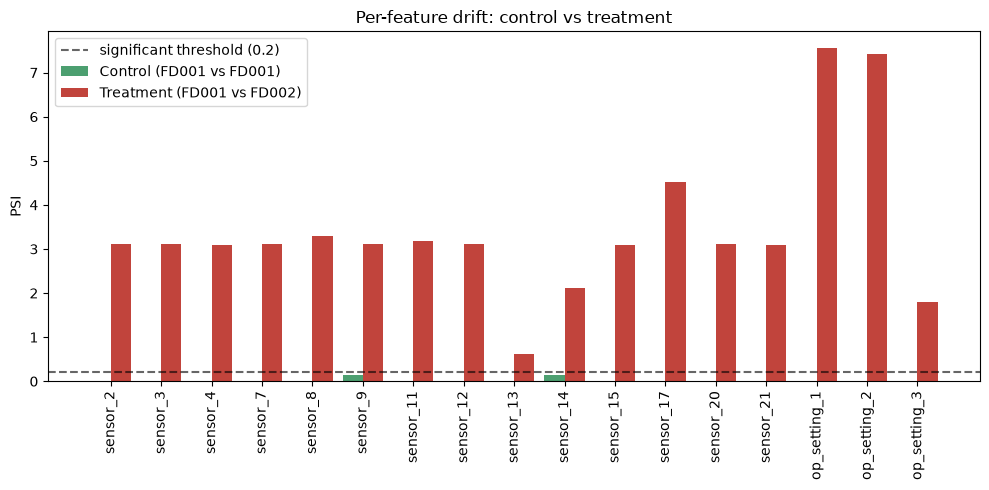

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(feature_cols))
w = 0.4
c = report_control.set_index('feature').reindex(feature_cols)['psi']
p = report_prod.set_index('feature').reindex(feature_cols)['psi']
ax.bar(x - w/2, c, w, label='Control (FD001 vs FD001)', color='#4C9F70')
ax.bar(x + w/2, p, w, label='Treatment (FD001 vs FD002)', color='#C1443C')
ax.axhline(0.2, color='k', ls='--', alpha=0.6, label='significant threshold (0.2)')
ax.set_xticks(x); ax.set_xticklabels(feature_cols, rotation=90)
ax.set_ylabel('PSI'); ax.set_title('Per-feature drift: control vs treatment')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Cross-check with Evidently (the production tool)

Same question, industry-standard implementation. Evidently also exports a rich
interactive HTML report — the kind of artifact a real monitoring stack surfaces
to a team. We save one for the drifted case.

In [6]:
ev_control = drift.evidently_report(reference, control, feature_cols)
ev_prod = drift.evidently_report(reference, production, feature_cols,
                                 html_path='../models/drift_report_fd002.html')

print("Evidently CONTROL  drift share:", ev_control['drift_share'])
print("Evidently TREATMENT drift share:", ev_prod['drift_share'])
print("HTML report saved:", ev_prod['html_saved'])

/opt/anaconda3/envs/ml-practice/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ml-practice/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ml-practice/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ml-practice/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ml-practice/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning:

invalid value encountered in divide

/opt/anaconda3/envs/ml-practice/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning:

invalid value encountered in 

Evidently CONTROL  drift share: 0.11764705882352941
Evidently TREATMENT drift share: 1.0
HTML report saved: ../models/drift_report_fd002.html


Both detectors should agree: near-zero drift on the control, substantial drift
on FD002. Hand-built = understanding; Evidently = production tooling.

## 4. The payoff: does drift actually predict model degradation?

A drift alarm is only useful if it *predicts real harm*. We train the model on
FD001 and evaluate it on both the control (FD001) and the drifted data (FD002).
If drift matters, **recall on the failure class should drop** on FD002.

In [7]:
# Train on FD001
X_train, y_train = data.get_xy(train_df)
clf = model.train(X_train, y_train)

# Evaluate on control (FD001 test) -- in-distribution
print("=== Model on CONTROL (FD001 test, no drift) ===")
X_ctrl, y_ctrl = data.get_xy(control)
m_ctrl = evaluate.evaluate(clf, X_ctrl, y_ctrl)

print("\n=== Model on DRIFTED data (FD002) ===")
X_prod, y_prod = data.get_xy(production)
m_prod = evaluate.evaluate(clf, X_prod, y_prod)

=== Model on CONTROL (FD001 test, no drift) ===
Accuracy (misleading on its own): 0.940

Confusion matrix [rows=actual, cols=predicted]:
               pred:Healthy  pred:FailSoon
  act:Healthy         3264           220
  act:FailSoon          26           594

Key metrics on the FAILURE class:
  recall    = 0.958  (fraction of real failures caught)
  precision = 0.730  (fraction of alarms that were real)
  f1        = 0.828

=== Model on DRIFTED data (FD002) ===
Accuracy (misleading on its own): 0.868

Confusion matrix [rows=actual, cols=predicted]:
               pred:Healthy  pred:FailSoon
  act:Healthy        45313           386
  act:FailSoon        6708          1352

Key metrics on the FAILURE class:
  recall    = 0.168  (fraction of real failures caught)
  precision = 0.778  (fraction of alarms that were real)
  f1        = 0.276


In [8]:
ctrl = m_ctrl['report']['Fail Soon']
prod = m_prod['report']['Fail Soon']
print("Failure-class performance:  CONTROL (FD001)  ->  DRIFTED (FD002)")
print(f"  recall:    {ctrl['recall']:.3f}  ->  {prod['recall']:.3f}")
print(f"  precision: {ctrl['precision']:.3f}  ->  {prod['precision']:.3f}")
print(f"  F1:        {ctrl['f1-score']:.3f}  ->  {prod['f1-score']:.3f}")
print(f"\nF1 change (overall failure-detection quality): "
      f"{prod['f1-score'] - ctrl['f1-score']:+.3f}")
print("\nNote: drift degrades the model, but WHICH metric suffers depends on "
      "how the shift breaks it — track F1 (both precision & recall), not just one.")

Failure-class performance:  CONTROL (FD001)  ->  DRIFTED (FD002)
  recall:    0.958  ->  0.168
  precision: 0.730  ->  0.778
  F1:        0.828  ->  0.276

F1 change (overall failure-detection quality): -0.552

Note: drift degrades the model, but WHICH metric suffers depends on how the shift breaks it — track F1 (both precision & recall), not just one.


## 5. Findings

- **Control (FD001 vs FD001 held-out):** PSI stayed low for every feature (max
  0.14, most < 0.01), correctly indicating no meaningful drift. However, the KS
  test flagged 10/17 features at p<0.05 — a false-alarm artifact of large sample
  size (~4,100 rows), where KS detects statistically-significant-but-practically-
  trivial differences. **Lesson: PSI's magnitude threshold is more trustworthy
  than KS significance on large samples.** Evidently's drift share was low (0.12),
  agreeing that the control is essentially stable.

- **Treatment (FD001 vs FD002):** unambiguous drift — 17/17 features flagged, max
  PSI 7.56, Evidently drift share 1.0. The highest-PSI features were the
  operating settings (op_setting_1/2 at ~7.5), which is physically correct: FD002
  runs under six operating conditions vs FD001's one, so the operating settings
  are exactly what should differ most.

- **Detector agreement:** hand-built PSI/KS and Evidently agreed strongly on the
  treatment (both maxed out). On the control they agreed on *magnitude* (low),
  differing only in KS's oversensitivity — itself an instructive result.

- **Model degradation (the payoff):** on drifted FD002 data, failure-class
  **recall collapsed from 0.958 → 0.168** and **F1 from 0.828 → 0.276** (a 0.55
  drop). The model missed ~83% of the real failures it caught in-distribution.
  Precision actually held (0.73 → 0.78), so here the damage fell on recall — the
  most dangerous failure mode for maintenance (missed failures).

### Honest conclusion
The monitor detects input drift *before* failure labels are available, and the
flagged drift corresponds to severe, concrete model degradation: an 83% collapse
in failures caught. The control also surfaced a real practical lesson — KS
significance is unreliable on large samples, so PSI magnitude (and Evidently's
share) are the signals to trust. FD002 differs from FD001 by design, so this is a
deliberately strong drift case; subtler production drift is harder to catch and
is where threshold tuning matters.

### Why this matters
This is the difference between *building* a model and *operating* one. A model
that silently starts missing 83% of failures — while throwing no errors — is the
nightmare scenario in production. This monitor is the smoke detector that catches
it from the input side, before the failures pile up.